# Phase 5 — Statistics, Randomness, Broadcasting and Matrix Maths

The last phase, and the one that connects most directly to what comes next. Almost
everything here shows up again the moment you open scikit-learn or PyTorch — usually hidden
inside a function you call, which is exactly why it's worth seeing it in the open once.

### What this notebook covers
1. Describing data with numbers (and one trap that makes NumPy disagree with Excel)
2. Finding *where* things are — `argmax`, `argsort`, `unique`
3. Random numbers, properly
4. **Broadcasting** — combining arrays of different sizes
5. **Fancy indexing** — grabbing any items you like, in any order
6. **Matrix maths** — the engine room of machine learning
7. `linspace` vs `arange`, and why `arange` lies about decimals

In [1]:
# ==========================================
# SETUP
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

## 1. Describing data with numbers

Given a pile of numbers, these tell you what's in it without you having to look at every
one. They all take `axis`, which works exactly as it did in Phase 3 — **the direction that
gets squashed away.**

A couple worth explaining rather than just listing:

- **Median** — the middle value when you line them all up. Unlike the mean, one freak value
  can't drag it around. (One billionaire walking into a café sends the *average* wealth
  through the roof; the *median* barely moves.)
- **Percentile** — "what value is X% of the data below?" The 25th percentile is the point a
  quarter of your data sits beneath.
- **IQR** — the gap between the 25th and 75th percentiles. It's the range covering the
  middle half of your data, ignoring the extremes at both ends.

In [2]:
# ==========================================
# 1a. THE STANDARD SUMMARY NUMBERS
# ==========================================
data = np.array([12, 7, 3, 14, 6, 11, 5, 4, 8, 9])

print("the data      :", data)
print("mean (average):", np.mean(data))
print("median (middle):", np.median(data))
print("std dev       :", np.std(data).round(4),  "← typical distance from the average")
print("variance      :", np.var(data).round(4),  "← std dev squared; used in formulas")
print("smallest / biggest:", np.min(data), "/", np.max(data))
print("range (ptp)   :", np.ptp(data),  "← 'peak to peak', biggest minus smallest")
print("25th percentile:", np.percentile(data, 25), "← a quarter of the data is below this")
print("75th percentile:", np.percentile(data, 75), "← three quarters is below this")
print("IQR           :", np.percentile(data, 75) - np.percentile(data, 25),
      "← the middle half lives in this range")
print("several at once:", np.percentile(data, [10, 50, 90]), "← ask for a list, get a list")

the data      : [12  7  3 14  6 11  5  4  8  9]
mean (average): 7.9
median (middle): 7.5
std dev       : 3.4191 ← typical distance from the average
variance      : 11.69 ← std dev squared; used in formulas
smallest / biggest: 3 / 14
range (ptp)   : 11 ← 'peak to peak', biggest minus smallest
25th percentile: 5.25 ← a quarter of the data is below this
75th percentile: 10.5 ← three quarters is below this
IQR           : 5.25 ← the middle half lives in this range
several at once: [ 3.9  7.5 12.2] ← ask for a list, get a list


### The trap that makes NumPy disagree with Excel

If you've ever computed a standard deviation in NumPy, then in Excel or pandas, and got two
different numbers — **this is why**, and nothing is broken.

Standard deviation is roughly "average distance from the average". The question is what you
divide by at the end:

- **Divide by N** (how many numbers you have) — correct when your data *is* the whole
  population. This is NumPy's default.
- **Divide by N − 1** — correct when your data is a *sample* drawn from a bigger population
  you can't see. This is what Excel's `STDEV`, pandas' `.std()`, and your statistics course
  all use.

Why the odd N − 1? A sample almost always looks a bit tighter than the population it came
from, because you probably missed the most extreme cases. Dividing by a slightly smaller
number nudges the answer up to compensate.

**In practice you're almost always working with a sample, so you usually want `ddof=1`.**
The gap is negligible on big datasets and large on small ones.

In [3]:
# ==========================================
# 1b. ddof — WHY YOUR NUMBER MIGHT NOT MATCH EXCEL'S
# ==========================================
print("np.std default (divide by N)  :", np.std(data).round(4))
print("np.std with ddof=1 (by N-1)   :", np.std(data, ddof=1).round(4),
      "← this is what pandas and Excel give you")

# On tiny datasets the difference is big; on large ones it shrinks to nothing
small = np.array([2, 4, 6])
print("\nwith only 3 numbers → by N:", np.std(small).round(4),
      "  by N-1:", np.std(small, ddof=1).round(4), "← a 22% difference!")

np.std default (divide by N)  : 3.4191
np.std with ddof=1 (by N-1)   : 3.604 ← this is what pandas and Excel give you

with only 3 numbers → by N: 1.633   by N-1: 2.0 ← a 22% difference!


In [4]:
# ==========================================
# 1c. STATISTICS ON A TABLE
# ==========================================
scores = np.array([[85, 90, 78],       # Ana's three subject marks
                   [92, 88, 76],       # Ben's
                   [70, 95, 83]])      # Cy's
subjects = np.array(['Math', 'Physics', 'Chemistry'])
students = np.array(['Ana', 'Ben', 'Cy'])

print("marks (rows = students, columns = subjects):\n", scores)

# axis=0 squashes the students away → one number per SUBJECT
print("\naverage per subject:", np.mean(scores, axis=0).round(2))

# axis=1 squashes the subjects away → one number per STUDENT
print("average per student:", np.mean(scores, axis=1).round(2))

print("spread per subject :", np.std(scores, axis=0).round(2),
      "← Math varies most, so it separates the students the best")

# argmin/argmax give positions, which we turn into names (the Phase 3 trick)
print("\nhardest subject:", subjects[np.argmin(np.mean(scores, axis=0))])
print("top student    :", students[np.argmax(np.mean(scores, axis=1))])

marks (rows = students, columns = subjects):
 [[85 90 78]
 [92 88 76]
 [70 95 83]]

average per subject: [82.33 91.   79.  ]
average per student: [84.33 85.33 82.67]
spread per subject : [9.18 2.94 2.94] ← Math varies most, so it separates the students the best

hardest subject: Chemistry
top student    : Ben


### Data with holes in it

As we saw in Phase 4, `nan` marks a missing value — and it spreads. One `nan` anywhere in
your data turns the average of the whole column into `nan`.

The `nan`-prefixed functions step over the gaps instead of choking on them.

In [5]:
# ==========================================
# 1d. STATISTICS THAT COPE WITH MISSING VALUES
# ==========================================
with_gaps = np.array([12.0, np.nan, 3.0, 14.0, np.nan, 11.0])

print("np.mean   :", np.mean(with_gaps),    "← two missing values ruined the answer")
print("np.nanmean:", np.nanmean(with_gaps).round(4), "← averages the four real numbers")
print("np.nansum :", np.nansum(with_gaps))
print("np.nanmax :", np.nanmax(with_gaps))
print("\nhow many are missing:", np.isnan(with_gaps).sum())

np.mean   : nan ← two missing values ruined the answer
np.nanmean: 10.0 ← averages the four real numbers
np.nansum : 40.0
np.nanmax : 14.0

how many are missing: 2


## 2. Finding *where* things are

The `arg` prefix means "**which one**". These don't give you values — they give you
**positions**, which you then use to look things up.

- `np.argmax` → where the biggest value sits
- `np.argsort` → the positions that would put things in order
- `np.unique` → the distinct values, with `return_counts=True` to tally them up

In [6]:
# ==========================================
# 2a. POSITIONS, NOT VALUES
# ==========================================
arr = np.array([3, 1, 4, 1, 5, 9, 2, 6, 5, 3])

print("the array      :", arr)
print("argmax         :", np.argmax(arr), "→ position 5, which holds", arr[np.argmax(arr)])
print("argmin         :", np.argmin(arr), "→ position 1, which holds", arr[np.argmin(arr)])
print("argsort        :", np.argsort(arr), "← the order to read them in to get them sorted")
print("reading in that order:", arr[np.argsort(arr)])
print("unique values  :", np.unique(arr), "← duplicates removed, sorted automatically")

# return_counts also tallies how often each one appears
values, counts = np.unique(arr, return_counts=True)
print("\nvalue → how many times:", dict(zip(values.tolist(), counts.tolist())))
print("most common    :", values[np.argmax(counts)],
      "← 1, 3 and 5 all appear twice; argmax just takes the first it finds")

the array      : [3 1 4 1 5 9 2 6 5 3]
argmax         : 5 → position 5, which holds 9
argmin         : 1 → position 1, which holds 1
argsort        : [1 3 6 0 9 2 4 8 7 5] ← the order to read them in to get them sorted
reading in that order: [1 1 2 3 3 4 5 5 6 9]
unique values  : [1 2 3 4 5 6 9] ← duplicates removed, sorted automatically

value → how many times: {1: 2, 2: 1, 3: 2, 4: 1, 5: 2, 6: 1, 9: 1}
most common    : 1 ← 1, 3 and 5 all appear twice; argmax just takes the first it finds


### `argmax` on a table, and `unravel_index`

On a 2-D table, `np.argmax` gives you **one** number, not a row and column. It pretends the
table has been unrolled into one long line and tells you the position along that line.

`np.unravel_index` rolls it back up, converting that single number into the `(row, column)`
you actually wanted.

In [7]:
# ==========================================
# 2b. FINDING THE BIGGEST CELL IN A TABLE
# ==========================================
grid = np.array([[3, 8, 1],
                 [9, 2, 7]])

flat_idx = np.argmax(grid)                              # a single "unrolled" position
row, col = np.unravel_index(flat_idx, grid.shape)       # rolled back into row + column

print("the grid:\n", grid)
print("\nargmax says       :", flat_idx,
      "← counting along as if the grid were one flat line of 6")
print("unravel_index says:", (int(row), int(col)), "→ that's the value", grid[row, col])

# Or ask per row / per column and skip the unravelling entirely
print("\nargmax(axis=0):", np.argmax(grid, axis=0), "← best ROW position, for each column")
print("argmax(axis=1):", np.argmax(grid, axis=1), "← best COLUMN position, for each row")

the grid:
 [[3 8 1]
 [9 2 7]]

argmax says       : 3 ← counting along as if the grid were one flat line of 6
unravel_index says: (1, 0) → that's the value 9

argmax(axis=0): [1 0 1] ← best ROW position, for each column
argmax(axis=1): [1 0] ← best COLUMN position, for each row


## 3. Random numbers

As Phase 1 mentioned, computers fake randomness from a starting number called a **seed**.
Same seed, same sequence, every time — which is what makes your results reproducible.

**Two APIs, and it's worth using the right one:**

- **Modern:** `rng = np.random.default_rng(42)` gives you a private generator. Nothing else
  in your program can disturb it.
- **Legacy:** `np.random.seed(42)` sets a single global seed shared with every library you've
  imported. If one of them reseeds it, your "reproducible" results quietly change.

New code should use the modern one. The old style is here because you'll meet it constantly
in tutorials and existing projects.

In [8]:
# ==========================================
# 3a. THE MODERN GENERATOR
# ==========================================
rng = np.random.default_rng(seed=42)      # our own private random-number machine

print("dice rolls        :", rng.integers(1, 7, size=10), "← 1 to 6 (the 7 is excluded)")
print("decimals 0 to 1   :", rng.random(5).round(3))
print("bell curve        :", rng.normal(0, 1, size=5).round(3), "← centred on 0")
print("bell curve, IQ-ish:", rng.normal(100, 15, size=5).round(1), "← centred on 100")

fruits = np.array(['apple', 'banana', 'cherry', 'date'])
print("\npick 3, no repeats:", rng.choice(fruits, size=3, replace=False))
print("pick 5, loaded odds:", rng.choice(fruits, size=5, p=[0.7, 0.1, 0.1, 0.1]),
      "← p says apple should win 70% of the time")

deck = np.arange(1, 6)
rng.shuffle(deck)                          # shuffles the array itself, returns nothing
print("\nshuffle (changes the original):", deck)
print("permutation (leaves it alone):", rng.permutation(np.arange(1, 6)))

dice rolls        : [1 5 4 3 3 6 1 5 2 1] ← 1 to 6 (the 7 is excluded)
decimals 0 to 1   : [0.976 0.761 0.786 0.128 0.45 ]
bell curve        : [0.879 0.778 0.066 1.127 0.468] ← centred on 0
bell curve, IQ-ish: [ 87.1 105.5  85.6 113.2  99.3] ← centred on 100

pick 3, no repeats: ['date' 'apple' 'cherry']
pick 5, loaded odds: ['cherry' 'banana' 'apple' 'apple' 'apple'] ← p says apple should win 70% of the time

shuffle (changes the original): [2 4 5 3 1]
permutation (leaves it alone): [1 2 3 5 4]


In [9]:
# ==========================================
# 3b. PROVING SEEDS MAKE THINGS REPEATABLE
# ==========================================
a = np.random.default_rng(7).random(3)     # two separate machines...
b = np.random.default_rng(7).random(3)     # ...both started from seed 7
print("same seed → same numbers:", np.array_equal(a, b))

# The old global style, for when you meet it in someone else's code
np.random.seed(42)
print("\nold style randint:", np.random.randint(1, 7, size=5))
print("old style randn  :", np.random.randn(3).round(3), "← 'randn' = random NORMAL")
print("old style rand   :", np.random.rand(3).round(3),  "← 'rand'  = random uniform")

same seed → same numbers: True

old style randint: [4 5 3 5 5]
old style randn  : [-0.234 -0.234  1.579] ← 'randn' = random NORMAL
old style rand   : [0.021 0.97  0.832] ← 'rand'  = random uniform


### Seeing the difference between two kinds of randomness

**Uniform** ("`rand`") — every value equally likely. Like a dice: 1 is exactly as likely
as 6.

**Normal** ("`randn`", the bell curve) — values near the middle are common, extremes are
rare. Like people's heights: loads around average, very few giants.

Almost anything you measure in the real world follows the second shape, which is why it
turns up everywhere in statistics and machine learning.

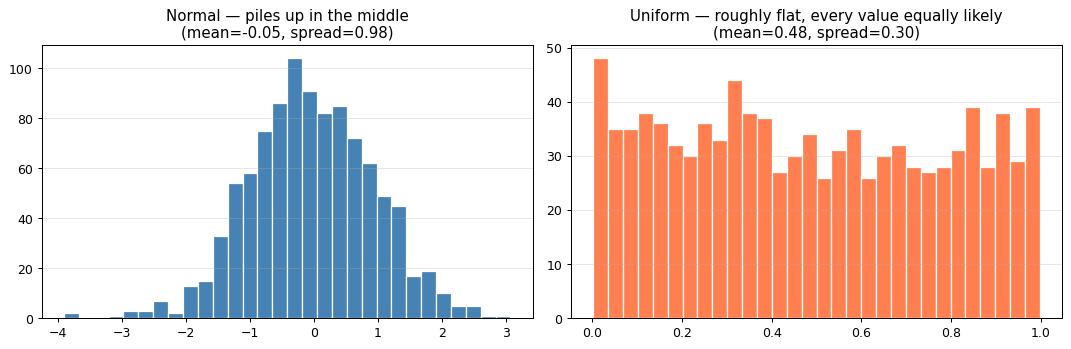

In [10]:
# ==========================================
# 3c. THE TWO SHAPES, SIDE BY SIDE
# ==========================================
rng = np.random.default_rng(0)
normal_data  = rng.normal(size=1000)      # 1000 draws from the bell curve
uniform_data = rng.random(1000)           # 1000 draws where everything's equally likely

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# A histogram sorts values into buckets and draws how full each bucket is
axes[0].hist(normal_data, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'Normal — piles up in the middle\n(mean={normal_data.mean():.2f}, '
                  f'spread={normal_data.std():.2f})')

axes[1].hist(uniform_data, bins=30, color='coral', edgecolor='white')
axes[1].set_title(f'Uniform — roughly flat, every value equally likely\n'
                  f'(mean={uniform_data.mean():.2f}, spread={uniform_data.std():.2f})')

for ax in axes:
    ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Broadcasting — combining arrays of different sizes

**Broadcasting** is NumPy's name for something you've already been doing without thinking:
`arr + 10` adds 10 to every item. The single number is "broadcast" out to meet each one.

The useful part is that this works between *arrays* too, not just with plain numbers — and
knowing the rule turns a whole class of "shapes not aligned" errors into a two-second fix.

### The rule

Line the two shapes up **from the right-hand end**, like adding numbers on paper. Then, for
each pair:

1. **Same number?** Fine.
2. **One of them is 1?** Fine — that one gets stretched to match.
3. **One array has run out of dimensions?** Fine — treat the missing slot as 1.
4. **Anything else?** Error.

```
    (3, 4)          (3, 4)          (3, 4)          (3, 4)
      (4,)   →      (3, 1)   →      (2, 4)   →        (3,)   →
  ---------      ---------      ---------      ---------
    (3, 4) ✓        (3, 4) ✓      ✗ 3 vs 2       ✗ 4 vs 3
```

**Nothing is actually copied.** NumPy doesn't build a stretched-out version in memory — it
just re-reads the same values as it goes. That's why broadcasting is both fast and free in
terms of memory.

In [11]:
# ==========================================
# 4a. BROADCASTING IN ACTION
# ==========================================

# The simplest case: one number stretched across everything
a = np.array([1, 2, 3, 4])
print("array + 10:", a + 10)

matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])

# A flat row of 3, shape (3,). Lined up from the right it becomes (1, 3),
# so it gets reused for EVERY row — the same three numbers added again and again.
row = np.array([10, 20, 30])
print("\n3x3 table + a row of 3:\n", matrix + row)

# A column, shape (3, 1). The 1 stretches sideways instead,
# so each value applies across a whole row.
col = np.array([[10], [20], [30]])
print("\n3x3 table + a column of 3:\n", matrix + col)
print("\nSame three numbers, completely different result — the SHAPE decided which.")

array + 10: [11 12 13 14]

3x3 table + a row of 3:
 [[11 22 33]
 [14 25 36]
 [17 28 39]]

3x3 table + a column of 3:
 [[11 12 13]
 [24 25 26]
 [37 38 39]]

Same three numbers, completely different result — the SHAPE decided which.


In [12]:
# ==========================================
# 4b. WHEN IT FAILS, AND THE ONE-LINE FIX
# ==========================================
m = np.arange(12).reshape(3, 4)      # shape (3, 4)
v = np.array([1, 2, 3])              # shape (3,)

# Lined up from the right: 3 sits under 4. They don't match and neither is 1.
try:
    m + v
except ValueError as e:
    print("ValueError:", e)

# THE FIX: stand v up as a column, making it (3, 1).
# Now the 1 is free to stretch across all 4 columns.
print("\nadding [:, np.newaxis] turns v into a column, and it works:")
print(m + v[:, np.newaxis])

ValueError: operands could not be broadcast together with shapes (3,4) (3,) 

adding [:, np.newaxis] turns v into a column, and it works:
[[ 1  2  3  4]
 [ 6  7  8  9]
 [11 12 13 14]]


In [13]:
# ==========================================
# 4c. THE OUTER-PRODUCT TRICK
# ==========================================
# A column (n, 1) against a row (1, m) gives you every combination — an (n, m) grid.
# Handy any time you need "each of these against each of those".
rows = np.arange(1, 5)[:, np.newaxis]     # (4, 1) — standing up
cols = np.arange(1, 6)[np.newaxis, :]     # (1, 5) — lying down

print("rows is", rows.shape, " cols is", cols.shape)
print("\nmultiply them and you get a times table:\n", rows * cols)

rows is (4, 1)  cols is (1, 5)

multiply them and you get a times table:
 [[ 1  2  3  4  5]
 [ 2  4  6  8 10]
 [ 3  6  9 12 15]
 [ 4  8 12 16 20]]


### The real-world use: putting columns on the same scale

Here's why broadcasting is worth learning properly.

Imagine three columns: square footage (~2000), number of bedrooms (~3), and price in
millions (~1.5). To most machine-learning algorithms, square footage looks a thousand times
more important than the others — **purely because its numbers happen to be bigger.** Nothing
about the data says that; it's an accident of units.

The fix is **standardising**: for each column, subtract that column's average and divide by
its spread. Afterwards every column is centred on 0 with a spread of 1, so they're compared
fairly.

This is exactly what scikit-learn's `StandardScaler` does. Two lines of broadcasting.

In [14]:
# ==========================================
# 4d. STANDARDISING EACH COLUMN
# ==========================================
data = np.array([[10, 200, 0.5],       # three columns on wildly different scales
                 [20, 150, 1.2],
                 [30, 180, 0.8]])

mean = data.mean(axis=0)     # (3,) — the average of each column
std  = data.std(axis=0)      # (3,) — the spread of each column

# (3,3) combined with (3,) → lined up from the right, 3 matches 3,
# so each column gets its own mean and spread applied down the rows
standardized = (data - mean) / std

print("before — the columns aren't comparable:\n", data)
print("\nafter — every column now speaks the same language:\n", standardized.round(3))
print("\ncolumn averages afterwards:", standardized.mean(axis=0).round(10), "→ all 0 ✓")
print("column spreads  afterwards:", standardized.std(axis=0).round(10),  "→ all 1 ✓")

before — the columns aren't comparable:
 [[ 10.  200.    0.5]
 [ 20.  150.    1.2]
 [ 30.  180.    0.8]]

after — every column now speaks the same language:
 [[-1.225  1.136 -1.162]
 [ 0.    -1.298  1.279]
 [ 1.225  0.162 -0.116]]

column averages afterwards: [ 0.  0. -0.] → all 0 ✓
column spreads  afterwards: [1. 1. 1.] → all 1 ✓


## 5. Fancy indexing — grab any items you like

So far you've selected items with slices (a range) or masks (a condition). **Fancy indexing**
is the third way: hand over a **list of the exact positions you want**.

Two things make it different from slicing:
- You can ask for **any order**, and **repeat** a position as often as you like.
- You always get back a **copy**, never a window onto the original.

In [15]:
# ==========================================
# 5a. PICKING EXACT POSITIONS
# ==========================================
arr = np.array([10, 20, 30, 40, 50, 60])

print("the array        :", arr)
print("positions 0, 2, 4:", arr[[0, 2, 4]])
print("in my own order  :", arr[[5, 0, 3]], "← last, first, then the fourth")
print("with repeats     :", arr[[1, 1, 1]], "← ask for the same one three times, why not")
print("reversed         :", arr[[5, 4, 3, 2, 1, 0]])

# It's a copy, so editing the result leaves the original alone
picked = arr[[0, 1]]
picked[0] = 999
print("\noriginal after editing the picked copy:", arr, "← untouched")

the array        : [10 20 30 40 50 60]
positions 0, 2, 4: [10 30 50]
in my own order  : [60 10 40] ← last, first, then the fourth
with repeats     : [20 20 20] ← ask for the same one three times, why not
reversed         : [60 50 40 30 20 10]

original after editing the picked copy: [10 20 30 40 50 60] ← untouched


In [16]:
# ==========================================
# 5b. FANCY INDEXING ON A TABLE
# ==========================================
matrix = np.array([[1,  2,  3],
                   [4,  5,  6],
                   [7,  8,  9],
                   [10, 11, 12]])

# One list → whole rows
print("rows 0 and 2:\n", matrix[[0, 2]])

# TWO lists → individual cells, paired up position by position.
# Reads as: (row 0, col 2), then (row 1, col 0), then (row 3, col 1)
rows = [0, 1, 3]
cols = [2, 0, 1]
print("\nthree specific cells:", matrix[rows, cols])

# Want the BLOCK where those rows meet those columns instead? Use np.ix_
print("\nthe block where rows 0 & 3 meet columns 0 & 2:\n", matrix[np.ix_([0, 3], [0, 2])])

rows 0 and 2:
 [[1 2 3]
 [7 8 9]]

three specific cells: [ 3  4 11]

the block where rows 0 & 3 meet columns 0 & 2:
 [[ 1  3]
 [10 12]]


In [17]:
# ==========================================
# 5c. TWO EVERYDAY USES
# ==========================================

# Use 1: writing to scattered positions in one go
arr = np.zeros(10, dtype=int)
arr[[1, 3, 5, 7]] = 9              # set four specific slots at once
print("scattered write:", arr)

# Use 2: re-ordering matching arrays together (the Phase 2 sorting trick again)
people = np.array(['Ana', 'Ben', 'Cy', 'Dee'])
ages   = np.array([31, 24, 45, 29])
order  = np.argsort(ages)          # the positions that put ages in order

print("\nsorted by age:", people[order], ages[order])
print("(the same 'order' applied to both, so names stay glued to their ages)")

scattered write: [0 9 0 9 0 9 0 9 0 0]

sorted by age: ['Ben' 'Dee' 'Ana' 'Cy'] [24 29 31 45]
(the same 'order' applied to both, so names stay glued to their ages)


## 6. Matrix maths

`np.linalg` ("linear algebra") is where NumPy meets machine learning. Linear regression, PCA
and every layer of a neural network are matrix operations underneath.

### The distinction that causes the most bugs

- **`*` multiplies item by item.** First item times first item, and so on. Shapes stay
  the same.
- **`@` is matrix multiplication** — the "row times column, add it up" operation from linear
  algebra. It's *not* item by item, and it changes the shape.

They're both valid Python on the same two arrays, so mixing them up gives you no error — just
a wrong answer. When you mean matrix multiplication, **write `@`**.

For `@` the shapes have to meet in the middle: `(n, k) @ (k, m)` gives `(n, m)`. The two
inner numbers must match, and they cancel out.

In [18]:
# ==========================================
# 6a. * vs @ — NOT THE SAME THING
# ==========================================
A = np.array([[2, 1],
              [5, 3]])
B = np.array([[1, 2],
              [3, 4]])

print("A * B — item by item:\n", A * B, "\n(2x1=2, 1x2=2, 5x3=15, 3x4=12)")
print("\nA @ B — matrix multiplication:\n", A @ B, "\n(each cell: a row of A dotted with a column of B)")
print("\nnp.dot(A, B) — the older name for @ :\n", np.dot(A, B))

# The shape rule: the inner numbers must match and cancel out
X = np.arange(6).reshape(2, 3)      # (2, 3)
Y = np.arange(6).reshape(3, 2)      # (3, 2)
print("\n(2,3) @ (3,2) → the 3s meet and cancel, leaving", (X @ Y).shape)

try:
    X @ X                            # (2,3) @ (2,3) — 3 and 2 in the middle don't match
except ValueError as e:
    print("(2,3) @ (2,3) fails:", str(e)[:70], "...")

A * B — item by item:
 [[ 2  2]
 [15 12]] 
(2x1=2, 1x2=2, 5x3=15, 3x4=12)

A @ B — matrix multiplication:
 [[ 5  8]
 [14 22]] 
(each cell: a row of A dotted with a column of B)

np.dot(A, B) — the older name for @ :
 [[ 5  8]
 [14 22]]

(2,3) @ (3,2) → the 3s meet and cancel, leaving (2, 2)
(2,3) @ (2,3) fails: matmul: Input operand 1 has a mismatch in its core dimension 0, with g ...


### Determinant, rank and inverse — in plain terms

- **Determinant** — one number summarising a matrix. The part you need to know: **if it's
  zero, the matrix has no inverse.** Think of it as a "is this reversible?" flag.
- **Rank** — how many genuinely independent rows there are. If one row is just another row
  doubled, it adds no new information and the rank drops.
- **Inverse** — the matrix equivalent of `1/x`. Multiply a matrix by its inverse and you get
  the identity matrix (matrix-land's number 1).

Same as with ordinary numbers, not everything can be inverted — you can't do `1/0`. A matrix
with a zero determinant is called **singular**, and asking for its inverse is an error.

In [19]:
# ==========================================
# 6b. INSPECTING AND INVERTING A MATRIX
# ==========================================
A = np.array([[2, 1],
              [5, 3]])

print("determinant:", np.linalg.det(A).round(10), "← not zero, so this one CAN be inverted")
print("rank       :", np.linalg.matrix_rank(A), "← 2 genuinely independent rows")
print("trace      :", np.trace(A), "← just the diagonal added up")

A_inv = np.linalg.inv(A)
print("\nthe inverse:\n", A_inv)
print("\nA @ its inverse — should be the identity:\n", (A @ A_inv).round(10))
print("close enough?", np.allclose(A @ A_inv, np.eye(2)),
      "← always compare decimals with allclose, never with ==, because of rounding")

# Now a matrix that CAN'T be inverted: row 2 is just row 1 doubled, so it adds nothing new
S = np.array([[1, 2],
              [2, 4]])
print("\nsingular matrix — determinant:", np.linalg.det(S).round(10),
      " rank:", np.linalg.matrix_rank(S), "← rank 1: really only one row's worth of info")
try:
    np.linalg.inv(S)
except np.linalg.LinAlgError as e:
    print("as expected:", e)

determinant: 1.0 ← not zero, so this one CAN be inverted
rank       : 2 ← 2 genuinely independent rows
trace      : 5 ← just the diagonal added up

the inverse:
 [[ 3. -1.]
 [-5.  2.]]

A @ its inverse — should be the identity:
 [[ 1.  0.]
 [-0.  1.]]
close enough? True ← always compare decimals with allclose, never with ==, because of rounding

singular matrix — determinant: 0.0  rank: 1 ← rank 1: really only one row's worth of info
as expected: Singular matrix


### Solving equations — and why you should avoid `inv`

Remember simultaneous equations from school?

```
2x +  y = 5
5x + 3y = 13
```

Write the coefficients as a matrix `A` and the answers as `b`, and `np.linalg.solve(A, b)`
does the rest.

You *could* instead compute `inv(A) @ b`, and plenty of tutorials do. **Don't.** Working out
a full inverse takes more steps, and every step adds a little rounding error, so you end up
with a slower answer that's also less accurate. `solve` goes straight to the result.

Rule of thumb: **outside of a lesson explaining what an inverse is, you almost never need
`inv`.**

In [20]:
# ==========================================
# 6c. SOLVING SIMULTANEOUS EQUATIONS
# ==========================================
# 2x +  y = 5
# 5x + 3y = 13
A = np.array([[2, 1],       # the numbers in front of x and y
              [5, 3]])
b = np.array([5, 13])       # what each equation equals

x = np.linalg.solve(A, b)
print("solution:", x, "→ x = 2, y = 1")
print("check it: does A @ x give us b back?", np.allclose(A @ x, b))

print("\nthe inv route:", (np.linalg.inv(A) @ b).round(10),
      "← same answer here, but slower and less accurate on bigger problems")

solution: [2. 1.] → x = 2, y = 1
check it: does A @ x give us b back? True

the inv route: [2. 1.] ← same answer here, but slower and less accurate on bigger problems


### Eigenvalues — the idea behind PCA

Multiplying a vector by a matrix usually **rotates it and stretches it**. But most matrices
have a few special directions that only get **stretched, never turned**. Those directions are
the **eigenvectors**, and how much each one stretches by is its **eigenvalue**.

Why anyone cares: those special directions are the ones along which your data varies most.
Find them and you can describe a 50-column dataset using its 5 most important directions.
That's PCA, and it's eigenvectors all the way down.

**Two practical notes:**
- `eig` returns eigenvectors as **columns**, not rows. `eigenvectors[:, 0]` is the first one.
- For lopsided matrices (a rotation, say) eigenvalues can come out as **complex numbers**
  with an imaginary part. If your matrix is symmetric — and covariance matrices, the ones
  PCA uses, always are — use **`eigh`** instead: it's faster and always gives real answers.

In [21]:
# ==========================================
# 6d. EIGENVALUES AND EIGENVECTORS
# ==========================================
C = np.array([[4, 2],
              [1, 3]])

eigenvalues, eigenvectors = np.linalg.eig(C)
print("eigenvalues (the stretch factors):", eigenvalues)
print("eigenvectors (one per COLUMN):\n", eigenvectors.round(4))

# The whole definition in one line: multiplying by C is the same as
# just scaling up, for these special directions
v   = eigenvectors[:, 0]        # the first special direction
lam = eigenvalues[0]            # how much it stretches

print("\nC @ v          :", (C @ v).round(6), "← put it through the matrix")
print("lambda * v     :", (lam * v).round(6), "← just multiply it by 5")
print("same thing?     ", np.allclose(C @ v, lam * v), "← that's what makes it special")

# A rotation matrix turns everything, so it has NO real unturned direction
rot = np.array([[0, -1],
                [1,  0]])
print("\neigenvalues of a rotation:", np.linalg.eig(rot).eigenvalues,
      "← complex. The 'j' means imaginary.")

eigenvalues (the stretch factors): [5. 2.]
eigenvectors (one per COLUMN):
 [[ 0.8944 -0.7071]
 [ 0.4472  0.7071]]

C @ v          : [4.472136 2.236068] ← put it through the matrix
lambda * v     : [4.472136 2.236068] ← just multiply it by 5
same thing?      True ← that's what makes it special

eigenvalues of a rotation: [0.+1.j 0.-1.j] ← complex. The 'j' means imaginary.


In [22]:
# ==========================================
# 6e. NORMS — HOW LONG IS THIS VECTOR?
# ==========================================
v = np.array([3, 4])
print("L2 / straight-line length:", np.linalg.norm(v),        "← Pythagoras: sqrt(3² + 4²)")
print("L1 / city-block length   :", np.linalg.norm(v, ord=1), "← 3 + 4, as if walking a grid")
print("L-infinity / biggest step:", np.linalg.norm(v, np.inf), "← just the largest one")

# Measure a whole batch at once: axis=1 gives one length per row
batch = np.array([[3, 4], [1, 1], [0, 5]])
print("\nlength of each row:", np.linalg.norm(batch, axis=1).round(4))

# Normalising: divide each row by its own length so every row ends up length 1.
# keepdims=True again — we need a column of lengths, not a flat run of them.
unit = batch / np.linalg.norm(batch, axis=1, keepdims=True)
print("\nafter normalising:\n", unit.round(4))
print("their lengths now:", np.linalg.norm(unit, axis=1).round(10), "→ all exactly 1 ✓")
print("(This is the step hiding inside cosine similarity from Phase 3.)")

L2 / straight-line length: 5.0 ← Pythagoras: sqrt(3² + 4²)
L1 / city-block length   : 7.0 ← 3 + 4, as if walking a grid
L-infinity / biggest step: 4.0 ← just the largest one

length of each row: [5.     1.4142 5.    ]

after normalising:
 [[0.6    0.8   ]
 [0.7071 0.7071]
 [0.     1.    ]]
their lengths now: [1. 1. 1.] → all exactly 1 ✓
(This is the step hiding inside cosine similarity from Phase 3.)


### Putting it together: fitting a line through noisy data

Here's linear regression built from nothing but linear algebra — the same job scikit-learn's
`LinearRegression` does, in about four lines.

We make some fake data along the line `y = 2.5x + 1`, scatter random noise over it, then ask
NumPy to work backwards and recover the original slope and intercept.

The one non-obvious bit is the **column of 1s**. A line needs two things: a slope and a
starting height (intercept). The `x` column handles the slope; the column of 1s is what lets
the intercept exist. Without it, your line is forced to pass through zero.

slope we recovered    : 2.454   (the real one was 2.5)
intercept we recovered: 1.087   (the real one was 1.0)
Close, but not exact — the noise makes perfect recovery impossible.


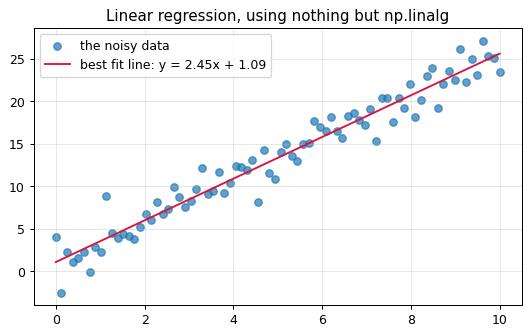

In [23]:
# ==========================================
# 6f. FITTING A STRAIGHT LINE (LINEAR REGRESSION)
# ==========================================
rng = np.random.default_rng(3)

# Step A: build fake data that follows y = 2.5x + 1, plus random scatter
x_data = np.linspace(0, 10, 80)
y_data = 2.5 * x_data + 1.0 + rng.normal(0, 1.5, size=80)

# Step B: build the "design matrix" — the x values, plus a column of 1s for the intercept
M = np.column_stack([x_data, np.ones_like(x_data)])

# Step C: least squares finds the line with the smallest total error
(slope, intercept), *_ = np.linalg.lstsq(M, y_data, rcond=None)

print(f"slope we recovered    : {slope:.3f}   (the real one was 2.5)")
print(f"intercept we recovered: {intercept:.3f}   (the real one was 1.0)")
print("Close, but not exact — the noise makes perfect recovery impossible.")

# Step D: draw it
plt.figure(figsize=(7, 4))
plt.scatter(x_data, y_data, label='the noisy data', alpha=0.7)
plt.plot(x_data, slope * x_data + intercept, color='crimson',
         label=f'best fit line: y = {slope:.2f}x + {intercept:.2f}')
plt.legend(); plt.grid(True, alpha=0.3)
plt.title('Linear regression, using nothing but np.linalg')
plt.show()

## 7. `linspace` vs `arange`

Both make a sequence. The difference is what you specify:

- **`np.arange(start, stop, step)`** — you give the **gap size**. NumPy works out how many
  numbers that produces.
- **`np.linspace(start, stop, count)`** — you give **how many numbers you want**. NumPy works
  out the gap. Both ends are included.

**For decimals, use `linspace`.** `arange` has to keep adding your step over and over, and
decimals can't be stored exactly in binary — 0.1 is really 0.1000000000000000055…. Those
tiny errors pile up, and you can end up with one more or one fewer number than you counted
on. With `linspace` you said how many you wanted, so you always get exactly that many.

In [24]:
# ==========================================
# 7a. THE DIFFERENCE, AND arange's ROUNDING PROBLEM
# ==========================================
print("arange(0, 1, 0.1)  :", np.arange(0, 1, 0.1))
print("  → that's", len(np.arange(0, 1, 0.1)), "numbers, and 1.0 never appears (stop is excluded)")

print("\nlinspace(0, 1, 11) :", np.linspace(0, 1, 11))
print("  → exactly 11 numbers, and 1.0 IS included")

# Here's arange going genuinely wrong. 'stop' is supposed to be excluded...
bad = np.arange(1, 1.3, 0.1)
print("\narange(1, 1.3, 0.1):", bad, "→", len(bad), "numbers")
print("  → 1.3 is the 'excluded' stop, but rounding let it slip in.")
print("  → We expected 3 numbers (1.0, 1.1, 1.2) and got 4. This breaks loops.")
print("linspace(1, 1.2, 3) :", np.linspace(1, 1.2, 3), "→ exactly 3, exactly as asked")

# linspace normally includes both ends; endpoint=False drops the last one
print("\nlinspace(0, 1, 5, endpoint=False):", np.linspace(0, 1, 5, endpoint=False))

arange(0, 1, 0.1)  : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
  → that's 10 numbers, and 1.0 never appears (stop is excluded)

linspace(0, 1, 11) : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
  → exactly 11 numbers, and 1.0 IS included

arange(1, 1.3, 0.1): [1.  1.1 1.2 1.3] → 4 numbers
  → 1.3 is the 'excluded' stop, but rounding let it slip in.
  → We expected 3 numbers (1.0, 1.1, 1.2) and got 4. This breaks loops.
linspace(1, 1.2, 3) : [1.  1.1 1.2] → exactly 3, exactly as asked

linspace(0, 1, 5, endpoint=False): [0.  0.2 0.4 0.6 0.8]


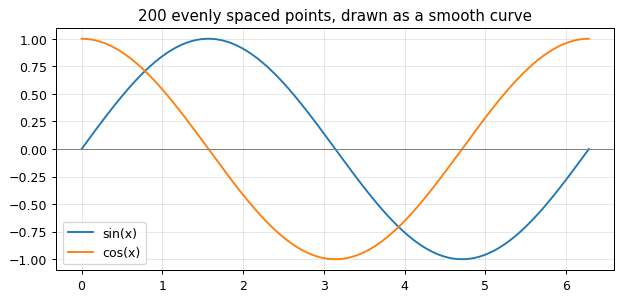

In [25]:
# ==========================================
# 7b. WHAT linspace IS ACTUALLY FOR: SMOOTH CURVES
# ==========================================
# 200 evenly spaced points across one full cycle. More points = smoother curve.
x = np.linspace(0, 2 * np.pi, 200)

plt.figure(figsize=(8, 3.5))
plt.plot(x, np.sin(x), label='sin(x)')       # sin applies to all 200 points at once
plt.plot(x, np.cos(x), label='cos(x)')
plt.axhline(0, color='gray', linewidth=0.8)  # a line along zero for reference
plt.title('200 evenly spaced points, drawn as a smooth curve')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## Cheat sheet

| What you want | What to type |
|---|---|
| Summary numbers | `mean`, `median`, `std(ddof=1)`, `var`, `percentile`, `ptp` |
| Summaries with gaps in the data | `nanmean`, `nansum`, `nanmax`, `np.isnan` |
| Where's the biggest? | `argmax`, `argmin`, `unravel_index` |
| Ranking / removing duplicates | `argsort`, `unique(..., return_counts=True)` |
| Random numbers | `rng = np.random.default_rng(42)`, then `random`, `integers`, `normal`, `choice` |
| Combine different-sized arrays | broadcasting; `[:, np.newaxis]` and `keepdims=True` to line them up |
| Pick exact items | `a[[i, j, k]]`, `a[rows, cols]`, `np.ix_` |
| Matrix multiply | `A @ B` (never `*`) |
| Solve equations | `np.linalg.solve(A, b)` (never `inv(A) @ b`) |
| Special directions (PCA) | `np.linalg.eig`, or `eigh` when the matrix is symmetric |
| Length of a vector | `np.linalg.norm(a, axis=1, keepdims=True)` |
| Fit a line | `np.linalg.lstsq` |
| Evenly spaced numbers | `np.linspace(start, stop, count)` |

### The five things worth memorising

1. **`np.std` divides by N; pandas and Excel divide by N−1.** Pass `ddof=1` to match them.
2. **Broadcasting lines shapes up from the right.** `newaxis` and `keepdims` are how you fix
   a mismatch.
3. **Fancy indexing copies; slicing gives you a window.**
4. **`*` is item by item; `@` is matrix multiplication.** No error will tell you which you
   meant.
5. **`solve` beats `inv`, and `linspace` beats `arange` for decimals.**

### Practice

1. Generate 1,000 bell-curve numbers averaging 50 with a spread of 10. Check that roughly
   68% land within one spread of the average — that's the famous property of the bell curve.
2. Take `np.array([[1,2],[3,4],[5,6]])` and subtract each **row's** own average from that
   row. (`keepdims` will be involved.)
3. Solve these three equations with `np.linalg.solve`:
   `3x + 2y − z = 1`, `2x − 2y + 4z = −2`, `−x + 0.5y − z = 0`.
4. Take 20 random whole numbers and find the 3 biggest **without sorting the whole lot**.
   *(Hint: `np.argpartition` — it only does enough work to split the big ones from the rest.)*

In [26]:
# ==========================================
# PRACTICE 1 — worked solution
# ==========================================
rng = np.random.default_rng(42)
samples = rng.normal(50, 10, size=1000)         # average 50, spread 10

# Which samples land within one spread of the average?
within_1_sd = np.abs(samples - samples.mean()) < samples.std()
print(f"within one spread: {within_1_sd.mean():.1%}   (theory predicts 68.3%)")

# ==========================================
# PRACTICE 2 — worked solution
# ==========================================
m = np.array([[1, 2], [3, 4], [5, 6]])
# keepdims=True gives a (3,1) column of averages that lines up against the (3,2) table
print("\neach row minus its own average:\n", m - m.mean(axis=1, keepdims=True))

# ==========================================
# PRACTICE 4 — worked solution
# ==========================================
nums = rng.integers(0, 100, size=20)
# argpartition shoves the 3 biggest to the end without bothering to order everything else
top3 = nums[np.argpartition(nums, -3)[-3:]]
print("\nthe numbers :", nums)
print("3 biggest   :", np.sort(top3)[::-1])

within one spread: 68.7%   (theory predicts 68.3%)

each row minus its own average:
 [[-0.5  0.5]
 [-0.5  0.5]
 [-0.5  0.5]]

the numbers : [18 64 40 34 69 40 46 44 25 12 82  9 32 66 13 65 73 66 30  1]
3 biggest   : [82 73 69]
